In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- 1. 數學模型設定 ---
def get_marginal_params(t, mu_init, sigma_init, theta, mu_ou, sigma_ou):
    """計算時間 t 的邊際分佈參數 N(M_t, V_t)"""
    exp_term = np.exp(-theta * t)
   
    M_t = mu_ou + (mu_init - mu_ou) * exp_term
   
    V_t = (sigma_init**2) * (exp_term**2) + \
          (sigma_ou**2 / (2 * theta)) * (1 - exp_term**2)
    return M_t, V_t

def get_marginal_score(x, t, mu_init, sigma_init, theta, mu_ou, sigma_ou):
    """計算邊際 Score: ∇ log p_t(x)"""
    M_t, V_t = get_marginal_params(t, mu_init, sigma_init, theta, mu_ou, sigma_ou)
    if V_t < 1e-6: return np.zeros_like(x)
    return -(x - M_t) / V_t

# --- 2. 模擬參數 ---
n_sims = 200        # 粒子數
theta = 0.8
mu_ou = 0.0         # OU mu
sigma_ou = 1.5      # noise level

T = 4.0             # 總時間
dt = 0.01
steps = int(T / dt)
t_axis = np.linspace(0, T, steps+1)


mu_init = 5.0       
sigma_init = 0.5    # init sigma(標準差)
x_fwd = np.zeros((steps+1, n_sims))
x_fwd[0] = np.random.normal(mu_init, sigma_init, n_sims) ###<<<<< Normal dist.

for i in range(steps):
    # Vectorized Euler-Maruyama
    x_curr = x_fwd[i]
    drift = theta * (mu_ou - x_curr)
    diffusion = sigma_ou
    dw = np.random.normal(0, np.sqrt(dt), n_sims)
    x_fwd[i+1] = x_curr + drift * dt + diffusion * dw

# --- 4. Reverse SDE (Generative / Denoising) ---
x_rev = np.zeros((steps+1, n_sims))
x_rev[-1] = x_fwd[-1]

for i in range(steps-1, -1, -1):
    t_curr = t_axis[i+1] 
    x_curr = x_rev[i+1]
    
    # Marginal Score 
    score = get_marginal_score(x_curr, t_curr, mu_init, sigma_init, theta, mu_ou, sigma_ou)
    
    # Reverse SDE : dX = [f(X) - g^2 * score] * (-dt) + g * dW
    f_x = theta * (mu_ou - x_curr)
    g_sq_score = (sigma_ou**2) * score
    rev_drift = f_x - g_sq_score
    
    dw = np.random.normal(0, np.sqrt(dt), n_sims)
    # 更新
    x_rev[i] = x_curr - rev_drift * dt + sigma_ou * dw



C:\Users\user\AppData\Local\Temp\ipykernel_12912\2409417884.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


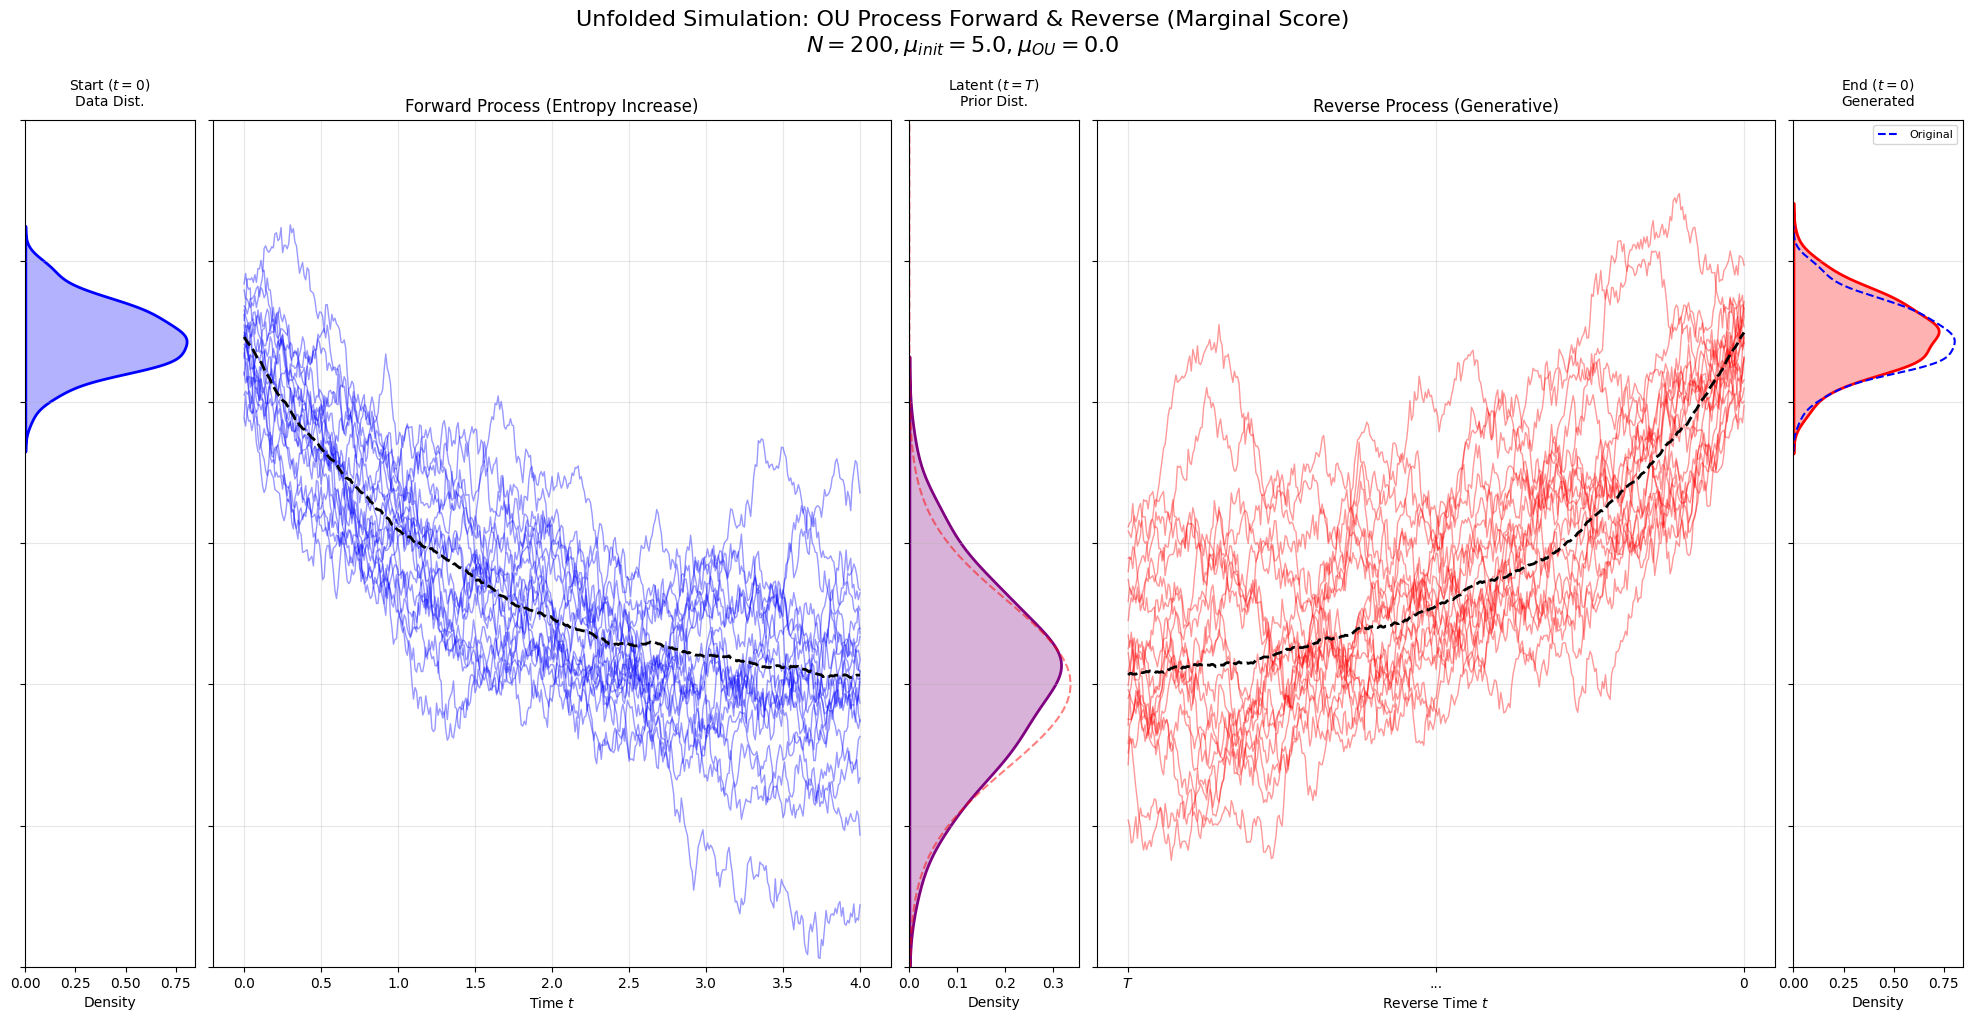

In [10]:
# --- 5. 進階視覺化 (GridSpec 佈局) ---
fig = plt.figure(figsize=(25, 11))

# 定義佈局: [PDF1] [Forward Paths] [PDF2] [Reverse Paths] [PDF3]
# width_ratios 控制每個區塊的寬度比例
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 4, 1, 4, 1], wspace=0.05)

ax_pdf_start = plt.subplot(gs[0])
ax_fwd = plt.subplot(gs[1], sharey=ax_pdf_start)
ax_pdf_mid = plt.subplot(gs[2], sharey=ax_pdf_start)
ax_rev = plt.subplot(gs[3], sharey=ax_pdf_start)
ax_pdf_end = plt.subplot(gs[4], sharey=ax_pdf_start)

# 設定統一的 Y 軸範圍以便觀察
y_lims = (-4, 8)

# --- 繪圖函數 helper ---
def plot_pdf(ax, data, color, label, title):
    sns.kdeplot(y=data, ax=ax, color=color, fill=True, alpha=0.3, linewidth=2)
    ax.set_ylim(y_lims)
    ax.set_title(title, fontsize=10, pad=10)
    ax.set_xlabel("Density")
    ax.grid(True, axis='y', alpha=0.3)
    # 移除多餘的軸標籤使其乾淨
    if ax != ax_pdf_start:
        ax.set_yticklabels([])

def plot_paths(ax, time_axis, data, color, title, is_reverse=False):
    # 隨機選 20 條畫出來就好，不然太亂
    indices = np.random.choice(n_sims, 20, replace=False)
    for idx in indices:
        ax.plot(time_axis, data[:, idx], color=color, alpha=0.4, linewidth=1)
    
    # 畫出平均路徑
    ax.plot(time_axis, np.mean(data, axis=1), color='black', linestyle='--', linewidth=2, label='Sample Mean')
    
    ax.set_ylim(y_lims)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    if is_reverse:
        # Reverse 的 X 軸標籤要反過來顯示物理意義，但數據是連續接續的
        # 這裡為了簡單，我們畫圖時讓 X 軸延續，但標籤可以自定義
        pass

# 1. 最左邊 PDF (t=0, Initial)
plot_pdf(ax_pdf_start, x_fwd[0], 'blue', 'Initial', 'Start ($t=0$)\nData Dist.')

# 2. Forward Paths (0 -> T)
plot_paths(ax_fwd, t_axis, x_fwd, 'blue', 'Forward Process (Entropy Increase)')
ax_fwd.set_xlabel('Time $t$')

# 3. 中間 PDF (t=T, Latent/Noise)
# 畫出理論的 OU 穩態分佈作為參考 (紅色虛線)
y_grid = np.linspace(*y_lims, 100)
steady_var = sigma_ou**2 / (2*theta)
steady_pdf = (1/np.sqrt(2*np.pi*steady_var)) * np.exp(-(y_grid - mu_ou)**2 / (2*steady_var))
ax_pdf_mid.plot(steady_pdf, y_grid, 'r--', alpha=0.5, label='Theoretical\nStationary')
plot_pdf(ax_pdf_mid, x_fwd[-1], 'purple', 'Latent', 'Latent ($t=T$)\nPrior Dist.')
# ax_pdf_mid.legend(fontsize=8)

# 4. Reverse Paths (T -> 0)
# 為了視覺上的連貫性，我們將時間軸平移: T -> 2T
reversed_time_axis = t_axis + T 
# 數據需要反轉順序畫 (因為 x_rev 索引 0 是 t=0_rec, 索引 -1 是 t=T)
# 但我們的 x_rev 存儲方式是: index 0 = t=0(結果), index -1 = t=T(起點)
# 為了符合「從左到右」的時間流，我們把 x_rev 倒過來畫
plot_paths(ax_rev, reversed_time_axis, x_rev[::-1], 'red', 'Reverse Process (Generative)')
ax_rev.set_xlabel('Reverse Time $t$')
# 修改 X 軸刻度顯示
xticks = [T, T + T/2, 2*T]
xticklabels = ['$T$', '...', '$0$']
ax_rev.set_xticks(xticks)
ax_rev.set_xticklabels(xticklabels)

# 5. 最右邊 PDF (t=0, Recovered)
plot_pdf(ax_pdf_end, x_rev[0], 'red', 'Recovered', 'End ($t=0$)\nGenerated')
# 把最左邊的原始分佈也畫上去比對 (藍色虛線)
sns.kdeplot(y=x_fwd[0], ax=ax_pdf_end, color='blue', linestyle='--', linewidth=1.5, label='Original')
ax_pdf_end.legend(fontsize=8, loc='upper right')

plt.suptitle(f"Unfolded Simulation: OU Process Forward & Reverse (Marginal Score)\n$N={n_sims}, \\mu_{{init}}={mu_init}, \\mu_{{OU}}={mu_ou}$", fontsize=16)
plt.tight_layout()
plt.show()


---

Epoch 0, Loss: 1.081882
Epoch 500, Loss: 0.268833
Epoch 1000, Loss: 0.228164
Epoch 1500, Loss: 0.399311
Epoch 2000, Loss: 0.145816
Epoch 2500, Loss: 0.802847
Epoch 3000, Loss: 0.080164
Epoch 3500, Loss: 0.754846
Epoch 4000, Loss: 0.348867
Epoch 4500, Loss: 0.230078
Epoch 0, Loss: 1.073273
Epoch 500, Loss: 0.580690
Epoch 1000, Loss: 0.145048
Epoch 1500, Loss: 0.650599
Epoch 2000, Loss: 1.790983
Epoch 2500, Loss: 0.516907
Epoch 3000, Loss: 0.785618
Epoch 3500, Loss: 0.222901
Epoch 4000, Loss: 0.397594
Epoch 4500, Loss: 0.489946


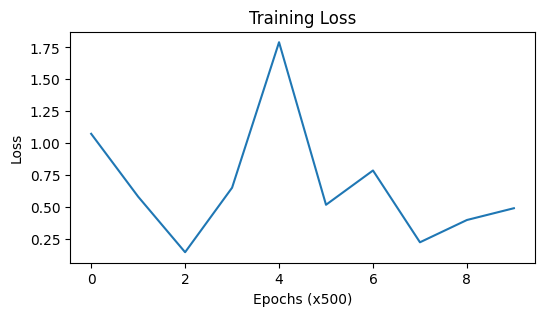

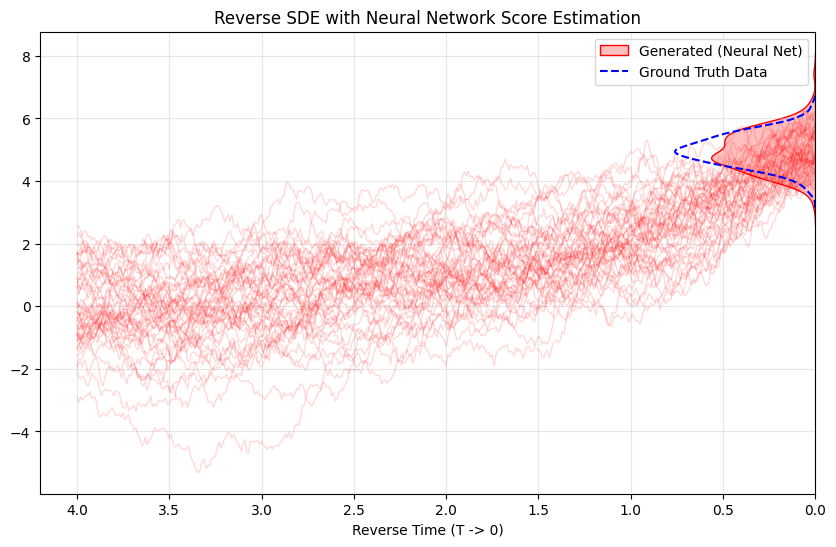

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 定義神經網路 (Score Network) ---
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 輸入是 x (狀態) 和 t (時間)，輸出是 score (梯度)
        # 這裡用一個簡單的 MLP: Input(2) -> Hidden(64) -> Hidden(64) -> Output(1)
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Softplus(), # 激活函數，Softplus 在物理相關問題通常比 ReLU 平滑好用
            nn.Linear(64, 64),
            nn.Softplus(),
            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        # x: [batch, 1], t: [batch, 1]
        input_data = torch.cat([x, t], dim=1)
        return self.net(input_data)

# --- 2. 輔助函數 (OU 過程參數) ---
# 這些跟之前一樣，用來生成訓練數據 (Ground Truth)
theta = 0.8
mu_ou = 0.0
sigma_ou = 1.5

def get_cond_mean_var(x0, t):
    """計算 p(x_t | x_0) 的均值與變異數 (條件機率)"""
    # 這是 Forward SDE 的解析解
    exp_term = torch.exp(-theta * t)
    mean_t = mu_ou + (x0 - mu_ou) * exp_term
    var_t = (sigma_ou**2 / (2 * theta)) * (1 - exp_term**2)
    return mean_t, var_t

# --- 3. 訓練迴圈 ---
def train_score_network(n_epochs=5000, batch_size=256): # Epochs 增加到 5000
    model = ScoreNet()
    # 修正點 1: 調小 Learning Rate
    optimizer = optim.Adam(model.parameters(), lr=5e-4) 
    
    loss_history = []
    
    for epoch in range(n_epochs):
        # ... (中間取樣邏輯不變) ...
        t = torch.rand(batch_size, 1) * 4.0 
        x0 = torch.randn(batch_size, 1) * 0.5 + 5.0
        mean_t, var_t = get_cond_mean_var(x0, t)
        std_t = torch.sqrt(var_t)
        noise = torch.randn_like(x0)
        xt = mean_t + std_t * noise
        target_score = -(xt - mean_t) / var_t
        
        pred_score = model(xt, t)
        loss = torch.mean((pred_score - target_score)**2)
        
        optimizer.zero_grad()
        loss.backward()
        
        # 修正點 2: 梯度裁剪 (Gradient Clipping) 防止數值爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        if epoch % 500 == 0: # 改成 500 印一次
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
            loss_history.append(loss.item())
            
    return model, loss_history # 回傳 loss 以便檢查

# --- 執行訓練 ---
trained_model = train_score_network()

# --- 4. 使用神經網路進行 Reverse Sampling (生成) ---
# 這邊的邏輯跟上一版一模一樣，只是 score 改成 call model
def neural_reverse_sampling(model, n_sims=200):
    T = 4.0
    dt = 0.01
    steps = int(T / dt)
    
    # 初始雜訊 (從 Forward 終點的分佈近似採樣，或直接用 Prior)
    # 為了對比，我們假設從完美的 Prior (OU穩態) 開始
    prior_std = np.sqrt(sigma_ou**2 / (2*theta))
    x_rev = torch.randn(n_sims, 1) * prior_std + mu_ou
    
    trajectory = [x_rev.numpy().flatten()]
    
    with torch.no_grad(): # 推論時不需要算梯度
        for i in range(steps):
            t_curr_val = T - i * dt # 時間倒數
            t_tensor = torch.ones(n_sims, 1) * t_curr_val
            
            # === 關鍵差異點 ===
            # 以前: score = get_marginal_score(...) (解析解)
            # 現在: score = model(x, t) (神經網路預測)
            score = model(x_rev, t_tensor)
            # =================
            
            # Reverse SDE Update
            # dX = [f(X) - g^2 * score] * (-dt) + g * dW
            f_x = theta * (mu_ou - x_rev)
            g_sq = sigma_ou**2
            rev_drift = f_x - g_sq * score
            
            dw = torch.randn_like(x_rev) * np.sqrt(dt)
            x_rev = x_rev - rev_drift * dt + sigma_ou * dw
            
            trajectory.append(x_rev.numpy().flatten())
            
    return np.array(trajectory)

# --- 5. 繪圖驗證 ---
# --- 修正後的執行流程 ---

# 1. 正確接收回傳值 (Unpacking)
trained_model, loss_history = train_score_network(n_epochs=5000)

# (可選) 畫一下 Loss 曲線確認訓練狀況
plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epochs (x500)")
plt.ylabel("Loss")
plt.show()

# 2. 再次執行採樣
# 確保這裡傳入的是 model 物件，而不是 tuple
neural_trajs = neural_reverse_sampling(trained_model)

# 3. 繪圖
plt.figure(figsize=(10, 6))
time_axis_rev = np.linspace(4.0, 0, neural_trajs.shape[0])

# 畫出部分路徑
for i in range(min(50, neural_trajs.shape[1])):
    plt.plot(time_axis_rev, neural_trajs[:, i], color='red', alpha=0.15, lw=1)

# 畫出最終生成的分布 (t=0)
sns.kdeplot(y=neural_trajs[-1, :], color='red', fill=True, label='Generated (Neural Net)')
# 畫出真實目標分布
target_dist = np.random.normal(5.0, 0.5, 1000)
sns.kdeplot(y=target_dist, color='blue', linestyle='--', label='Ground Truth Data')

plt.title("Reverse SDE with Neural Network Score Estimation")
plt.xlabel("Reverse Time (T -> 0)")
plt.legend()
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

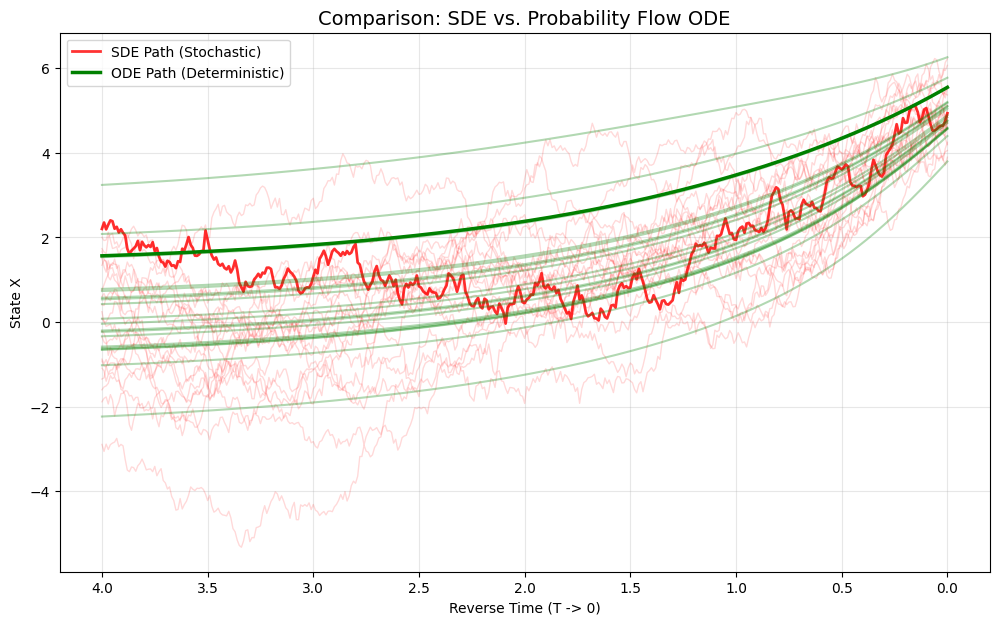

In [14]:
def neural_ode_sampling(model, n_sims=20):
    # 參數設定同上
    T = 4.0
    dt = 0.01 
    steps = int(T / dt)
    
    # 1. 初始點：從 Prior (OU 穩態) 採樣
    # 注意：ODE 對初始點非常敏感，因為它是確定性的。
    # 不同的初始雜訊會精確對應到不同的生成結果。
    prior_std = np.sqrt(sigma_ou**2 / (2*theta))
    x_ode = torch.randn(n_sims, 1) * prior_std + mu_ou
    
    trajectory = [x_ode.numpy().flatten()]
    
    with torch.no_grad():
        for i in range(steps):
            t_curr_val = T - i * dt 
            t_tensor = torch.ones(n_sims, 1) * t_curr_val
            
            # 預測 Score
            score = model(x_ode, t_tensor)
            
            # --- Probability Flow ODE 公式 ---
            # dX = [f(x) - 0.5 * g^2 * score] * (-dt)
            # 注意係數是 0.5 * sigma^2
            f_x = theta * (mu_ou - x_ode)
            g_sq = sigma_ou**2
            
            # ODE Drift term
            ode_drift = f_x - 0.5 * g_sq * score
            
            # 更新 (沒有 + sigma * dw 的隨機項)
            x_ode = x_ode - ode_drift * dt
            
            trajectory.append(x_ode.numpy().flatten())
            
    return np.array(trajectory)

# --- 執行並繪圖 ---
# 1. 生成 ODE 軌跡 (綠色)
ode_trajs = neural_ode_sampling(trained_model, n_sims=20)

# 2. 為了對比，我們取 SDE 的前 20 條軌跡 (紅色)
# (假設 neural_trajs 變數還在記憶體中，如果不在請重新執行上一段 SDE sampling)
sde_trajs = neural_trajs[:, :20] 

plt.figure(figsize=(12, 7))
time_axis_rev = np.linspace(4.0, 0, ode_trajs.shape[0])

# 畫 SDE (紅色，抖動)
for i in range(sde_trajs.shape[1]):
    plt.plot(time_axis_rev, sde_trajs[:, i], color='red', alpha=0.15, lw=1)
# 畫 SDE 的一條代表線 (加粗)
plt.plot(time_axis_rev, sde_trajs[:, 0], color='red', alpha=0.8, lw=2, label='SDE Path (Stochastic)')

# 畫 ODE (綠色，平滑)
for i in range(ode_trajs.shape[1]):
    plt.plot(time_axis_rev, ode_trajs[:, i], color='green', alpha=0.3, lw=1.5)
# 畫 ODE 的一條代表線 (加粗)
plt.plot(time_axis_rev, ode_trajs[:, 0], color='green', alpha=1.0, lw=2.5, label='ODE Path (Deterministic)')

# 畫目標分佈
plt.title("Comparison: SDE vs. Probability Flow ODE", fontsize=14)
plt.xlabel("Reverse Time (T -> 0)")
plt.ylabel("State X")
plt.legend()
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()